# Mean-degree model at $C\propto N$: β, higher moments, growth tent

Characterize the **mean-degree** normalization (`kind="powerlaw"`, pl2.5 graph) at the
size-independent scaling $C\propto N$ found earlier ($C=C_0\,N/N_0$, anchor $(4000,100)$).
Here $N=8000\Rightarrow C=200$.

Measured, pooling ~20 realizations:
- **β** — size-volatility exponent $\sigma(\bar S)\sim\bar S^{-\beta}$ (decline branch)
- **higher moments** — $E[\sigma^q\mid S]\sim S^{-\zeta_q}$, $q=1..4$, and the ratios $\zeta_q/\zeta_1$
  vs the granular-flat and MSB references
- **growth-rate distribution** — the tent $g=\Delta\ln S$

The plots show the **binned data points against the fitted lines** so you can judge visually whether
each log-log relation is actually straight (a clean power law) or curved, and whether the tent is
fat-tailed and symmetric.

In [1]:
import os, sys, time
while not os.path.isdir("relative_glv") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")                                          # run from repo root OR notebooks/
sys.path.insert(0, os.getcwd())
import numpy as np
from scipy.stats import laplace, kurtosis
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from relative_glv.model import coupling, integrate, growth_rate
from relative_glv.msb import size_volatility, tent_stats, rescale

SMOKE = os.environ.get("MC_SMOKE", "0") == "1"
MU, SIGMA, LAM = 1.76, 1.75, 1e-3
N0, C0 = 4000, 100                                  # C ∝ N anchor
N = 1500 if SMOKE else int(os.environ.get("MC_N", 8000))
Cdeg = max(2, round(C0 * N / N0))                   # C ∝ N  -> 200 at N=8000, 800 at N=32000
SEEDS = 3 if SMOKE else int(os.environ.get("MC_SEEDS", 20))
TMAX, N_EVAL = (100.0, 400) if SMOKE else (250.0, 700)
LATE, DT = ((75.0, 98.0) if SMOKE else (180.0, 240.0)), 0.5
NB, NJOBS = 20, int(os.environ.get("MC_NJOBS", 6))
TAG = "" if N == 8000 or SMOKE else f"_N{N}"        # non-default sizes get their own output files
print(f"{'SMOKE ' if SMOKE else ''}mean-degree pl2.5  N={N}  C={Cdeg} (C∝N)  {SEEDS} seeds  "
      f"mu={MU} sigma={SIGMA} lam={LAM}  window={LATE}  njobs={NJOBS}  tag='{TAG}'")

mean-degree pl2.5  N=16000  C=400 (C∝N)  20 seeds  mu=1.76 sigma=1.75 lam=0.001  window=(180.0, 240.0)  njobs=6  tag='_N16000'


In [2]:
def simulate(seed):
    a = coupling(N, MU, SIGMA, kind="powerlaw", seed=seed, mean_degree=Cdeg)
    r = integrate(a, tmax=TMAX, n_eval=N_EVAL, lam=LAM, seed=seed,
                  method="RK45", rtol=1e-4, atol=1e-7)
    if not r["success"]:
        return None
    sv = size_volatility(r["W"], r["t"], window=LATE, dt=DT, n_bins=NB)
    if sv["growth"].size == 0 or not np.isfinite(sv["beta"]):
        return None
    return dict(Sbar=sv["Sbar"], vol=sv["vol"], growth=sv["growth"], beta=float(sv["beta"]),
                r2=float(sv["r2"]), g_eff=growth_rate(r["t"], r["lnM"], frac=0.3))

t0 = time.time()
recs = [x for x in Parallel(n_jobs=NJOBS, backend="loky")(
    delayed(simulate)(s) for s in range(SEEDS)) if x is not None]
assert recs, "no economies survived"
Sbar = np.concatenate([x["Sbar"] for x in recs])
vol = np.concatenate([x["vol"] for x in recs])
growth = np.vstack([x["growth"] for x in recs])
econ = np.concatenate([np.full(x["Sbar"].size, i) for i, x in enumerate(recs)])
live = (vol > 0) & np.isfinite(vol) & (Sbar > 0)
Sbar, vol, growth, econ = Sbar[live], vol[live], growth[live], econ[live]
beta_med = float(np.median([x["beta"] for x in recs]))
beta_sd = float(np.std([x["beta"] for x in recs]))
print(f"survived {len(recs)}/{SEEDS}   pooled firms={Sbar.size}   "
      f"beta(median per-economy)={beta_med:.3f} ± {beta_sd:.3f}   "
      f"g_eff~{np.median([x['g_eff'] for x in recs]):+.2f}   ({(time.time()-t0)/60:.1f} min)")

survived 20/20   pooled firms=42074   beta(median per-economy)=0.449 ± 0.064   g_eff~+0.19   (7.1 min)


In [3]:
def multiscaling(Sbar, vol, econ, nb=NB, nboot=300):
    """zeta_1..4 from E[sigma^q|S]~S^-zeta_q on the decline branch, with per-q fit R^2 (linearity)
    and bootstrap-over-economy errors. Same estimator as scripts/msb_conditional.py."""
    o = np.argsort(Sbar); P = np.array_split(np.arange(o.size), nb)
    bx = np.array([Sbar[o][p].mean() for p in P]); by = np.array([np.median(vol[o][p]) for p in P])
    m = (bx > 0) & (by > 0); bx, by = bx[m], by[m]
    pk = int(np.argmax(by)); Scut = bx[pk]; dec = Sbar > Scut
    nfit = max(6, nb - pk)
    def cq_of(Sx, vx, want_r2=False):
        ox = np.argsort(Sx); Px = np.array_split(np.arange(ox.size), nfit)
        bxx = np.array([Sx[ox][p].mean() for p in Px]); out = []; D2 = []; r2 = []
        for q in (1, 2, 3, 4):
            byy = np.array([np.mean(vx[ox][p] ** q) for p in Px]); D2.append(byy)
            mm = (bxx > 0) & (byy > 0)
            c = np.polyfit(np.log10(bxx[mm]), np.log10(byy[mm]), 1)
            out.append(-c[0])
            if want_r2:
                yh = np.polyval(c, np.log10(bxx[mm])); lg = np.log10(byy[mm])
                ss = np.sum((lg - lg.mean()) ** 2)
                r2.append(1 - np.sum((lg - yh) ** 2) / ss if ss > 0 else np.nan)
        return np.array(out), bxx, np.array(D2), np.array(r2) if want_r2 else None
    cq, bxd, D2M, r2q = cq_of(Sbar[dec], vol[dec], want_r2=True)
    ue = np.unique(econ[dec]); rbs = np.random.default_rng(0); boot = []
    for _ in range(nboot):
        pick = rbs.choice(ue, ue.size, replace=True)
        ix = np.concatenate([np.where(econ[dec] == e)[0] for e in pick])
        boot.append(cq_of(Sbar[dec][ix], vol[dec][ix])[0])
    boot = np.array(boot)
    return dict(cq=cq, cq_err=boot.std(0), r2q=r2q, ratio=cq / cq[0],
                ratio_err=(boot / boot[:, [0]]).std(0), bxd=bxd, D2M=D2M,
                bin_S=bx, bin_vol=by, pk=pk, Scut=float(Scut))

def quenched(Sbar, vol, econ, nb=NB):
    """Quenched average: fit zeta_q in each economy separately (own peak cut), THEN average the
    exponents over economies. Pooling first (annealed) mixes economies whose sigma(S) curves sit at
    different levels, which can bend the pooled log-log relation; the quenched mean cannot."""
    Z = []
    for e in np.unique(econ):
        S, v = Sbar[econ == e], vol[econ == e]
        o = np.argsort(S); P = np.array_split(np.arange(o.size), nb)
        bx = np.array([S[o][p].mean() for p in P]); by = np.array([np.median(v[o][p]) for p in P])
        m = (bx > 0) & (by > 0); bx, by = bx[m], by[m]
        pk = int(np.argmax(by)); dec = S > bx[pk]
        Sx, vx = S[dec], v[dec]
        ox = np.argsort(Sx); Px = np.array_split(np.arange(ox.size), max(6, nb - pk))
        bxx = np.array([Sx[ox][p].mean() for p in Px]); zq = []
        for q in (1, 2, 3, 4):
            byy = np.array([np.mean(vx[ox][p] ** q) for p in Px])
            mm = (bxx > 0) & (byy > 0)
            zq.append(-np.polyfit(np.log10(bxx[mm]), np.log10(byy[mm]), 1)[0])
        Z.append(zq)
    Z = np.array(Z); R = Z / Z[:, [0]]; n = Z.shape[0]
    return dict(Z=Z, cq=Z.mean(0), cq_err=Z.std(0) / np.sqrt(n),
                ratio=R.mean(0), ratio_err=R.std(0) / np.sqrt(n), n=n)

ms = multiscaling(Sbar, vol, econ)
qn = quenched(Sbar, vol, econ)
ts = tent_stats(growth)
print("higher moments  E[sigma^q|S] ~ S^-zeta_q  (decline branch; MSB data zeta ~ 0.20,0.39,0.51,0.58)")
print("        pooled (annealed)         quenched (per-economy fit, then mean)")
for q in (1, 2, 3, 4):
    print(f"  q={q}:  zeta_{q} = {ms['cq'][q-1]:+.3f} ± {ms['cq_err'][q-1]:.3f} (R2={ms['r2q'][q-1]:.2f})"
          f"   zeta_{q} = {qn['cq'][q-1]:+.3f} ± {qn['cq_err'][q-1]:.3f}")
print(f"\nratios zeta_q/zeta_1   pooled   = {np.round(ms['ratio'],2).tolist()}")
print(f"                       quenched = {np.round(qn['ratio'],2).tolist()} "
      f"± {np.round(qn['ratio_err'],2).tolist()}   ({qn['n']} economies)")
print("                       (granular flat 1,1,1,1 ; MSB data 1, 2.0, 2.6, 2.9)")
print(f"growth tent: Bowley skew = {ts['bowley']:+.3f} (0=symmetric)   "
      f"excess kurtosis = {ts['exkurt']:.2f} (Gaussian 0, Laplace 3)")

higher moments  E[sigma^q|S] ~ S^-zeta_q  (decline branch; MSB data zeta ~ 0.20,0.39,0.51,0.58)
        pooled (annealed)         quenched (per-economy fit, then mean)
  q=1:  zeta_1 = +0.372 ± 0.020 (R2=0.99)   zeta_1 = +0.410 ± 0.013
  q=2:  zeta_2 = +0.658 ± 0.041 (R2=0.99)   zeta_2 = +0.757 ± 0.025
  q=3:  zeta_3 = +0.862 ± 0.063 (R2=0.98)   zeta_3 = +1.034 ± 0.036
  q=4:  zeta_4 = +0.993 ± 0.084 (R2=0.98)   zeta_4 = +1.244 ± 0.045

ratios zeta_q/zeta_1   pooled   = [1.0, 1.77, 2.32, 2.67]
                       quenched = [1.0, 1.84, 2.51, 3.02] ± [0.0, 0.01, 0.02, 0.04]   (20 economies)
                       (granular flat 1,1,1,1 ; MSB data 1, 2.0, 2.6, 2.9)
growth tent: Bowley skew = +0.013 (0=symmetric)   excess kurtosis = 7.09 (Gaussian 0, Laplace 3)


D1  rescaled vol sigma/sigmabar(S) (decline branch): size-collapse + bounded tail
     small S: median=0.97  P90=1.37  P99=1.78
       mid S: median=0.95  P90=1.45  P99=1.98
     large S: median=0.91  P90=1.55  P99=2.28
     tail P99/median: pooled=2.16  per-economy rescale=1.98  (bounded/thin if collapse holds; own-degree script value for comparison)

D3  un-mixed growth ghat=(g-gbar)/sigma_i (decline branch)   (Gaussian -> exkurt 0)
     pooled excess kurtosis: homogeneous-rescale=7.27  per-firm-unmixed=3.93
     exkurt of ghat vs size (8 bins, small->large):  2.0  2.8  3.1  3.6  4.0  4.4  5.0  5.9
     trend d(exkurt)/d(log S) = +6.37   (<0 = Gaussianizes with size [granular/CLT]; >=0 = MSB: stays/gets fatter)


     quenched: trend = +6.49 ± 0.52 over 20 economies (20 positive)   mean exkurt small->large:  2.2  3.0  3.6  4.1  4.7  5.7


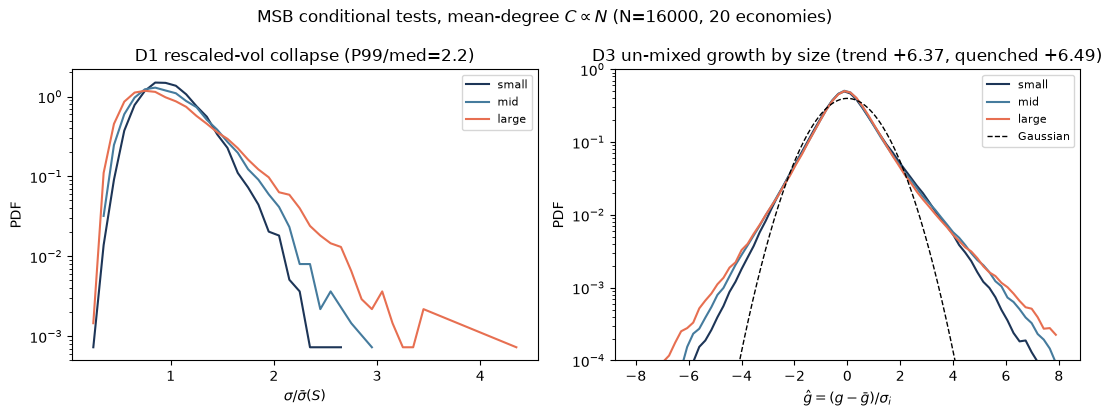

In [4]:
# MSB's other two discriminating tests (D1, D3 of scripts/msb_conditional.py), same estimators
# so the numbers are directly comparable with the own-degree run.
dec = Sbar > ms["Scut"]
o = np.argsort(Sbar[dec]); Sd, vd = Sbar[dec][o], vol[dec][o]
P = np.array_split(np.arange(Sd.size), len(ms["bxd"]))

# D1: rescaled-volatility collapse. sigma_i/sigmabar(S) should be size-INDEPENDENT with a bounded
# tail (MSB data: Inverse-Gamma). Granular models predict a hump from few-sub-unit firms.
sbar_S = np.interp(Sbar[dec], ms["bxd"], np.array([np.mean(vd[p]) for p in P]))
rr = vol[dec] / sbar_S
# quenched variant: rescale by each ECONOMY's own sigmabar_e(S), so cross-economy level
# differences (today's pooling lesson) cannot masquerade as tail weight
rr_q = np.full(dec.sum(), np.nan)
for e in np.unique(econ[dec]):
    m = econ[dec] == e
    Se, ve = Sbar[dec][m], vol[dec][m]
    oe = np.argsort(Se); Pe = np.array_split(np.arange(Se.size), max(6, len(ms["bxd"]) // 2))
    bxe = np.array([Se[oe][p].mean() for p in Pe])
    bye = np.array([np.mean(ve[oe][p]) for p in Pe])
    rr_q[m] = ve / np.interp(Se, bxe, bye)
lo, mid, hi = np.array_split(np.argsort(Sbar[dec]), 3)
print("D1  rescaled vol sigma/sigmabar(S) (decline branch): size-collapse + bounded tail")
for nm, idx in (("small", lo), ("mid", mid), ("large", hi)):
    print(f"     {nm:>5} S: median={np.median(rr[idx]):.2f}  P90={np.percentile(rr[idx],90):.2f}  "
          f"P99={np.percentile(rr[idx],99):.2f}")
d1_tail = float(np.percentile(rr, 99) / np.median(rr))
d1_tail_q = float(np.percentile(rr_q, 99) / np.median(rr_q))
print(f"     tail P99/median: pooled={d1_tail:.2f}  per-economy rescale={d1_tail_q:.2f}  "
      f"(bounded/thin if collapse holds; own-degree script value for comparison)")

# D3: un-mix growth by each firm's own vol; does it Gaussianize with size? (granular/CLT: yes;
# MSB data: no -- large firms stay at least as fat-tailed)
gres = growth - growth.mean(1, keepdims=True)
ghat = gres / vol[:, None]
raw = gres[dec].ravel(); raw = raw[np.isfinite(raw)]
raw = raw / (np.sqrt(np.pi / 2) * np.abs(raw).mean())
pooled_g = ghat[dec].ravel(); pooled_g = pooled_g[np.isfinite(pooled_g)]
k_homog, k_unmix = float(kurtosis(raw)), float(kurtosis(pooled_g))
od = np.argsort(Sbar[dec]); Q = np.array_split(od, 8)
bxk = np.array([Sbar[dec][q].mean() for q in Q])
bk = np.array([kurtosis(ghat[dec][q].ravel()) for q in Q])
d3_trend = float(np.polyfit(np.log10(bxk), bk, 1)[0])
print("\nD3  un-mixed growth ghat=(g-gbar)/sigma_i (decline branch)   (Gaussian -> exkurt 0)")
print(f"     pooled excess kurtosis: homogeneous-rescale={k_homog:.2f}  per-firm-unmixed={k_unmix:.2f}")
print("     exkurt of ghat vs size (8 bins, small->large):  " + "  ".join(f"{v:.1f}" for v in bk))
print(f"     trend d(exkurt)/d(log S) = {d3_trend:+.2f}   "
      f"(<0 = Gaussianizes with size [granular/CLT]; >=0 = MSB: stays/gets fatter)")

# quenched D3: kurtosis-vs-size WITHIN each economy, then average curves/trends. A pooled mixture
# of economies with different ghat shapes is fatter than its components, so the pooled kurtosis
# (and possibly its trend) can be inflated; the per-economy average cannot.
NBK = 6
K_e, tr_e = [], []
for e in np.unique(econ[dec]):
    m = econ[dec] == e
    if m.sum() < 8 * NBK:
        continue
    oe = np.argsort(Sbar[dec][m]); Qe = np.array_split(oe, NBK)
    bxe = np.array([Sbar[dec][m][q].mean() for q in Qe])
    bke = np.array([kurtosis(ghat[dec][m][q].ravel()) for q in Qe])
    K_e.append(bke); tr_e.append(np.polyfit(np.log10(bxe), bke, 1)[0])
K_e, tr_e = np.array(K_e), np.array(tr_e)
d3_trend_q = float(tr_e.mean()); d3_trend_q_err = float(tr_e.std() / np.sqrt(tr_e.size))
print(f"     quenched: trend = {d3_trend_q:+.2f} ± {d3_trend_q_err:.2f} over {tr_e.size} economies "
      f"({int(np.sum(tr_e > 0))} positive)   mean exkurt small->large:  "
      + "  ".join(f"{v:.1f}" for v in K_e.mean(0)))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
tercol = {"small": "#1d3557", "mid": "#457b9d", "large": "#e76f51"}
for nm, idx in (("small", lo), ("mid", mid), ("large", hi)):
    h, e = np.histogram(rr[idx], bins=50, range=(0, 5), density=True); m = h > 0
    ax[0].semilogy(0.5 * (e[:-1] + e[1:])[m], h[m], color=tercol[nm], label=nm)
ax[0].set(xlabel=r"$\sigma/\bar\sigma(S)$", ylabel="PDF",
          title=f"D1 rescaled-vol collapse (P99/med={d1_tail:.1f})")
ax[0].legend(fontsize=8)
zz = np.linspace(-8, 8, 200)
for nm, idx in (("small", lo), ("mid", mid), ("large", hi)):
    gg = ghat[dec][idx].ravel(); gg = gg[np.isfinite(gg)]
    h, e = np.histogram(gg, bins=70, range=(-8, 8), density=True); m = h > 0
    ax[1].semilogy(0.5 * (e[:-1] + e[1:])[m], h[m], color=tercol[nm], label=nm)
ax[1].semilogy(zz, np.exp(-zz ** 2 / 2) / np.sqrt(2 * np.pi), "k--", lw=1, label="Gaussian")
ax[1].set(xlabel=r"$\hat g=(g-\bar g)/\sigma_i$", ylabel="PDF", ylim=(1e-4, 1),
          title=f"D3 un-mixed growth by size (trend {d3_trend:+.2f}, quenched {d3_trend_q:+.2f})")
ax[1].legend(fontsize=8)
fig.suptitle(f"MSB conditional tests, mean-degree $C\\propto N$ (N={N}, {len(recs)} economies)")
plt.tight_layout()
plt.savefig(f"data/meandeg_characterize_conditional{TAG}.png", dpi=120)
plt.show()

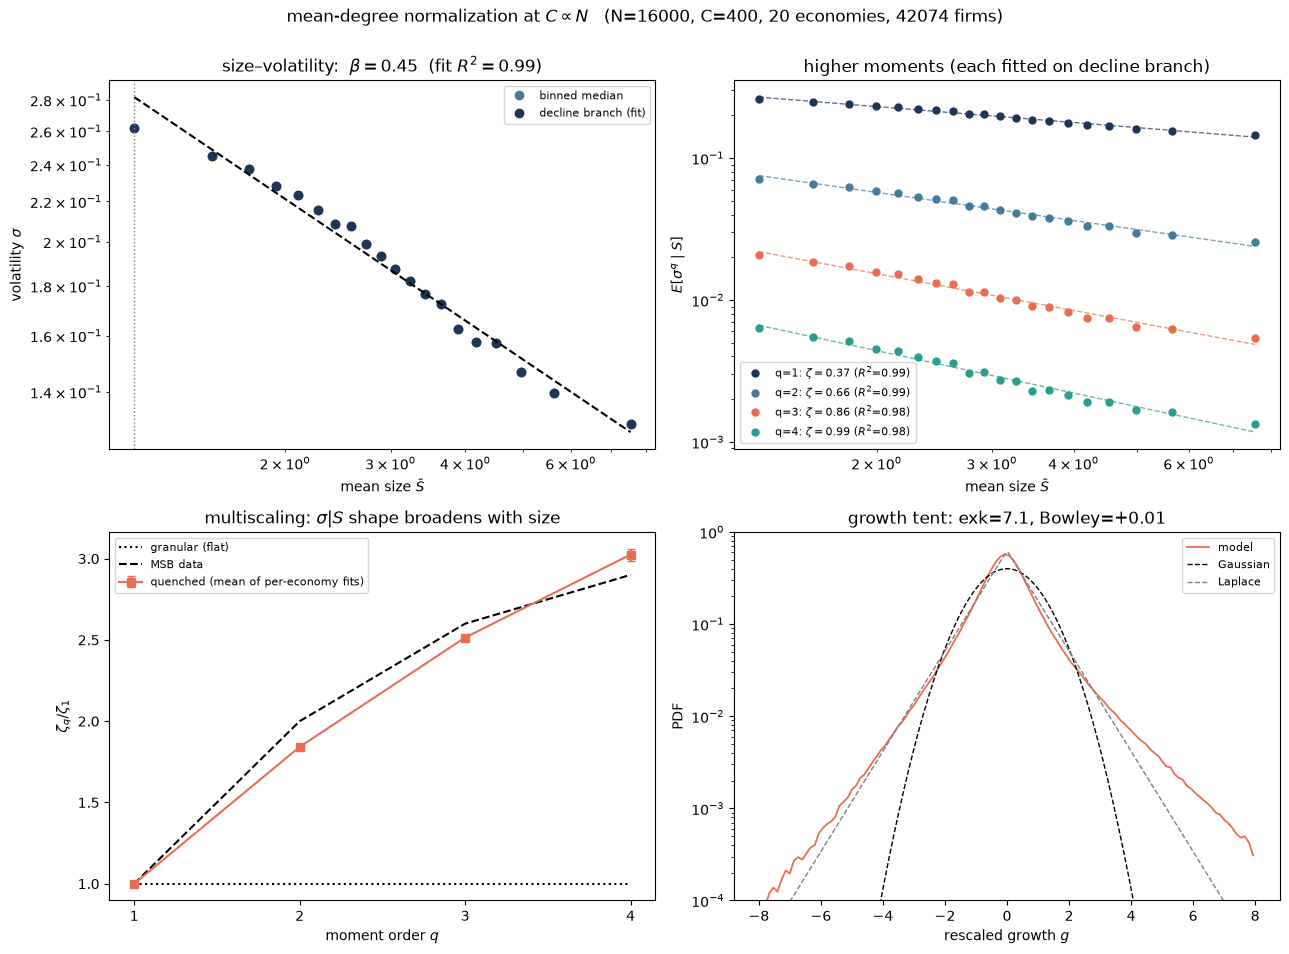

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9.5))
qs = np.array([1, 2, 3, 4]); qcol = ["#1d3557", "#457b9d", "#e76f51", "#2a9d8f"]

# (0,0) size-volatility: full binned curve + decline-branch fit -> is the decline STRAIGHT?
bx, by, pk = ms["bin_S"], ms["bin_vol"], ms["pk"]
ax[0, 0].loglog(bx, by, "o", ms=6, color="#457b9d", label="binned median")
ax[0, 0].loglog(bx[pk:], by[pk:], "o", ms=6, color="#1d3557", label="decline branch (fit)")
xf = np.array([bx[pk], bx[-1]]); cf = np.polyfit(np.log10(bx[pk:]), np.log10(by[pk:]), 1)
ax[0, 0].loglog(xf, 10 ** np.polyval(cf, np.log10(xf)), "k--", lw=1.5)
ax[0, 0].axvline(ms["Scut"], color="grey", ls=":", lw=1)
ax[0, 0].set(xlabel=r"mean size $\bar S$", ylabel=r"volatility $\sigma$",
             title=fr"size–volatility:  $\beta={beta_med:.2f}$  (fit $R^2={ms['r2q'][0]:.2f}$)")
ax[0, 0].legend(fontsize=8)

# (0,1) higher moments E[sigma^q|S] with fit lines -> is each one STRAIGHT?
bxd, D2M = ms["bxd"], ms["D2M"]
for i, q in enumerate(qs):
    ax[0, 1].loglog(bxd, D2M[i], "o", ms=5, color=qcol[i],
                    label=fr"q={q}: $\zeta={ms['cq'][i]:.2f}$ ($R^2$={ms['r2q'][i]:.2f})")
    cf = np.polyfit(np.log10(bxd), np.log10(D2M[i]), 1)
    ax[0, 1].loglog(bxd, 10 ** np.polyval(cf, np.log10(bxd)), "--", lw=1, color=qcol[i], alpha=0.7)
ax[0, 1].set(xlabel=r"mean size $\bar S$", ylabel=r"$E[\sigma^q\mid S]$",
             title="higher moments (each fitted on decline branch)")
ax[0, 1].legend(fontsize=8)

# (1,0) multiscaling ratio zeta_q/zeta_1: quenched vs references
ax[1, 0].errorbar(qs, qn["ratio"], yerr=qn["ratio_err"], marker="s", ms=6, capsize=3,
                  color="#e76f51", label="quenched (mean of per-economy fits)")
ax[1, 0].plot(qs, [1, 1, 1, 1], "k:", lw=1.5, label="granular (flat)")
ax[1, 0].plot(qs, [1, 2.0, 2.6, 2.9], "k--", lw=1.5, label="MSB data")
ax[1, 0].set(xlabel="moment order $q$", ylabel=r"$\zeta_q/\zeta_1$", xticks=qs,
             title=r"multiscaling: $\sigma|S$ shape broadens with size")
ax[1, 0].legend(fontsize=8)

# (1,1) growth tent
z = rescale(growth); zz = np.linspace(-8, 8, 200)
h, e = np.histogram(z, bins=120, range=(-8, 8), density=True); m = h > 0
ax[1, 1].semilogy(0.5 * (e[:-1] + e[1:])[m], h[m], lw=1.3, color="#e76f51", label="model")
ax[1, 1].semilogy(zz, np.exp(-zz ** 2 / 2) / np.sqrt(2 * np.pi), "k--", lw=1, label="Gaussian")
ax[1, 1].semilogy(zz, laplace.pdf(zz, scale=np.sqrt(2 / np.pi)), "0.5", ls="--", lw=1, label="Laplace")
ax[1, 1].set(xlabel=r"rescaled growth $g$", ylabel="PDF", ylim=(1e-4, 1),
             title=fr"growth tent: exk={ts['exkurt']:.1f}, Bowley={ts['bowley']:+.2f}")
ax[1, 1].legend(fontsize=8)

fig.suptitle(f"mean-degree normalization at $C\\propto N$   (N={N}, C={Cdeg}, {len(recs)} economies, "
             f"{Sbar.size} firms)", y=1.00)
plt.tight_layout()
plt.savefig(f"data/meandeg_characterize{TAG}.png", dpi=120)
plt.show()

In [6]:
np.savez(f"data/meandeg_characterize{TAG}.npz", N=N, C=Cdeg, seeds=len(recs), n_firms=int(Sbar.size),
         beta=beta_med, beta_sd=beta_sd, cq=ms["cq"], cq_err=ms["cq_err"], r2q=ms["r2q"],
         ratio=ms["ratio"], ratio_err=ms["ratio_err"], bin_S=ms["bin_S"], bin_vol=ms["bin_vol"],
         cq_quenched=qn["cq"], cq_quenched_err=qn["cq_err"], ratio_quenched=qn["ratio"],
         ratio_quenched_err=qn["ratio_err"], zeta_per_econ=qn["Z"],
         d2_S=ms["bxd"], d2_M=ms["D2M"], bowley=ts["bowley"], exk=ts["exkurt"],
         d1_tail=d1_tail, d1_tail_quenched=d1_tail_q,
         d1_r=rr[::max(1, rr.size // 50000)].astype(np.float32),
         d3_S=bxk, d3_kurt=bk, d3_trend=d3_trend, d3_k_homog=k_homog, d3_k_unmix=k_unmix,
         d3_kurt_per_econ=K_e, d3_trend_per_econ=tr_e,
         d3_trend_quenched=d3_trend_q, d3_trend_quenched_err=d3_trend_q_err,
         tent_z=rescale(growth)[::max(1, growth.size // 40000)].astype(np.float32))
print(f"saved data/meandeg_characterize{TAG}.npz/.png and _conditional{TAG}.png")

saved data/meandeg_characterize_N16000.npz/.png and _conditional_N16000.png


## How to read the panels

- **Top-left (size–volatility):** is the dark decline branch a **straight line** on log-log? If yes,
  $\sigma(\bar S)\sim\bar S^{-\beta}$ is a clean power law and β is well-defined. Curvature means the
  single exponent is only approximate. (The light small-$\bar S$ points are the immigration-floor
  plateau, excluded from the fit.)
- **Top-right (higher moments):** each $q$ should be straight and parallel-ish; the per-$q$ $R^2$
  quantifies it. Steeper slopes at higher $q$ = multiscaling.
- **Bottom-left (ratios):** **quenched estimator only** (fit each economy, then average the
  exponents). The pooled/annealed fit is printed above but not plotted: concatenating economies
  whose $\sigma(S)$ curves sit at different levels bends the pooled log-log relation, biasing
  $\zeta_q$ low, and the bias has no seed-count limit. On the MSB dashed line = reproduces the
  size-growing correlations; on the flat dotted line = granular/no multiscaling. A fixed-shape
  $\sigma|S$ slice would give $\zeta_q/\zeta_1=q$; anything below that means the slice shape
  **broadens with size** — the multiscaling.
- **Bottom-right (tent):** heavier-than-Gaussian and roughly symmetric (Bowley≈0) = the fat-tailed
  growth fact.

## MSB conditional tests (D1/D3 figure)

The multiscaling above is MSB's first discriminating test. The extra cell runs the other two
(same estimators as `scripts/msb_conditional.py`, which measures them on the own-degree model):

- **D1 (left):** the per-firm volatility rescaled by its size-conditional mean,
  $\sigma_i/\bar\sigma(S)$, should **collapse** onto one size-independent shape with a **bounded**
  tail (MSB data: Inverse-Gamma). A fat tail here is the hub-over-coupling risk of the mean-degree
  normalization. The per-economy-rescaled tail number strips cross-economy level mixing.
- **D3 (right):** growth un-mixed by each firm's own volatility, $(g-\bar g)/\sigma_i$, should stay
  **fat-tailed at every size** (trend $\geq 0$); Gaussianizing with size (trend $<0$) is the
  granular/CLT signature the data reject.

Change `N` at the top (C tracks it by $C\propto N$) to confirm the picture is size-stable.